In [ ]:
# Setup and imports

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# Import GcStar from causalised-GC
import importlib.util
import sys
CAUSALISED_GC_RELATIVE_PATH = Path("src/markovianity_diagnostic/core/causalised-GC.py")
PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / CAUSALISED_GC_RELATIVE_PATH).exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find '{CAUSALISED_GC_RELATIVE_PATH}' from {Path.cwd().resolve()}"
    )
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
CAUSALISED_GC_PATH = PROJECT_ROOT / CAUSALISED_GC_RELATIVE_PATH
spec = importlib.util.spec_from_file_location("causalised_gc", CAUSALISED_GC_PATH)
causalised_gc = importlib.util.module_from_spec(spec)
sys.modules["causalised_gc"] = causalised_gc
assert spec.loader is not None
spec.loader.exec_module(causalised_gc)
GcStar = causalised_gc.GcStar

from markovianity_diagnostic.core.utils import adj_mtx, continuous_noise_fun
from markovianity_diagnostic.experiments.graph_metrics import compute_graph_stability_metrics

print("✓ All imports successful")

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


In [ ]:
metrics, N_PASTS, num = [], list(range(2,8)), 10
shd_sids = []
for a in tqdm(range(num)):
    n_neur,l,alpha,beta,n_lags = np.random.randint(20,30,1)[0],np.random.randint(5000,10000,1)[0],0.01,0.001,2

    #     creating A matrix

    A = np.random.choice([0,0.5,0.85], p=[0.9,0.035,0.065], size=(n_neur,n_neur)) ### A is not the adjacency matrix in the typical sense
    A[0:10,0:10] =np.zeros((10,10))
    for n, i in enumerate(A):
        A[n][n]=1
    for n, i in enumerate(A):
        A[n]=A[n]/np.sum(A[n])

    #     creating B matrix
    mask = np.random.random((A.shape[0],A.shape[1]))>0.55
    np.fill_diagonal(mask,1)
    B_ = np.multiply(A,1-mask)
    A_ = np.multiply(A,mask)

    A = np.logical_or(A_, B_)

    noise = continuous_noise_fun(num=n_neur,l=l)

    X = np.zeros((A.shape[0],l)).T
    X[0] = np.random.randn(A.shape[0])
    for i, row in enumerate(X[:-1]):
        X[i+1] = A_ @ X[i] + B_ @ X[i-1] + np.random.normal(0,0.25,A.shape[0])
    X=X.T

    print(f'Data {a} of {num} with {X.shape[0]} vars')

    # fit algorithm to data
    met = np.zeros((len(N_PASTS), 6))
    shd_sid_fgc = []
    infs_fgc = []
    conf_mtx_fgc = []
    metrics_fgc = []

    for k, n_past in enumerate(N_PASTS):
        print(n_past)

        # intantiate the GcStar()
        gcstar = GcStar(n_perm = 1000, n_pasts = n_past, n_lags = n_lags, temporal = True, method="cgc")
        gcstar.fit(X, verbose=0)

        # compute metrics
        inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=True)
        infs_fgc.append(inf)
        conf_mtx_fgc.append(gcstar.compute_confusion_matrix(A, simulation=True))
        met[k] = np.round(gcstar.all_metrics(), 4)
        metrics_fgc.append(np.round(gcstar.all_metrics(),4))
        shd_sid_fgc.append(np.round(gcstar.compute_shd_sid(A, inf, simulation=True),4))

    metrics.append(met)
    shd_sids.append(shd_sid_fgc)


  0%|          | 0/10 [00:00<?, ?it/s]

Data 0 of 10 with 21 vars
2
3
4
5
6
7
Data 1 of 10 with 29 vars
2
3
4
5
6
7
Data 2 of 10 with 20 vars
2
3
4
5
6
7
Data 3 of 10 with 20 vars
2
3
4
5
6
7
Data 4 of 10 with 20 vars
2
3
4
5
6
7
Data 5 of 10 with 28 vars
2
3
4
5
6
7
Data 6 of 10 with 24 vars
2
3
4
5
6
7
Data 7 of 10 with 24 vars
2
3
4
5
6
7
Data 8 of 10 with 20 vars
2
3
4
5
6
7
Data 9 of 10 with 23 vars
2
3
4
5
6
7


In [3]:
for met in metrics:
    print(met)

[[0.9592 0.6897 1.     0.0449 0.9776 0.8163]
 [0.9569 0.678  1.     0.0474 0.9763 0.8081]
 [0.9592 0.6897 1.     0.0449 0.9776 0.8163]
 [0.9592 0.6897 1.     0.0449 0.9776 0.8163]
 [0.9546 0.6667 1.     0.0499 0.9751 0.8   ]
 [0.9546 0.6667 1.     0.0499 0.9751 0.8   ]]
[[0.9453 0.6    1.     0.0596 0.9702 0.75  ]
 [0.9489 0.6161 1.     0.0557 0.9722 0.7624]
 [0.9441 0.5948 1.     0.0609 0.9696 0.7459]
 [0.9465 0.6053 1.     0.0583 0.9709 0.7541]
 [0.9441 0.5948 1.     0.0609 0.9696 0.7459]
 [0.9453 0.6    1.     0.0596 0.9702 0.75  ]]
[[0.9575 0.6341 0.9286 0.0403 0.9441 0.7536]
 [0.9575 0.6341 0.9286 0.0403 0.9441 0.7536]
 [0.955  0.619  0.9286 0.043  0.9428 0.7429]
 [0.955  0.619  0.9286 0.043  0.9428 0.7429]
 [0.9575 0.6341 0.9286 0.0403 0.9441 0.7536]
 [0.9575 0.6341 0.9286 0.0403 0.9441 0.7536]]
[[0.9625 0.6429 1.     0.0402 0.9799 0.7826]
 [0.96   0.6279 1.     0.0429 0.9786 0.7714]
 [0.9625 0.6429 1.     0.0402 0.9799 0.7826]
 [0.9675 0.675  1.     0.0349 0.9826 0.806 ]
 [0.962

In [4]:
Metrics = np.zeros((num,len(N_PASTS), 6))
for i, met in enumerate(metrics):
    Metrics[i] = met
np.mean(Metrics[:,0,0])

np.float64(0.95602)

In [5]:
np.std(Metrics,axis=0)

array([[0.01044479, 0.06732605, 0.04689593, 0.01192996, 0.02274167,
        0.05030547],
       [0.00956739, 0.06288704, 0.04689593, 0.01087785, 0.02276424,
        0.04837797],
       [0.01043859, 0.06952867, 0.04689593, 0.01174758, 0.02301462,
        0.05237902],
       [0.01037017, 0.06575579, 0.04316346, 0.0115963 , 0.02132004,
        0.05049875],
       [0.01056634, 0.06745143, 0.04316346, 0.01243794, 0.02040174,
        0.04865507],
       [0.01116579, 0.06842187, 0.04689593, 0.01276989, 0.0228201 ,
        0.05124799]])

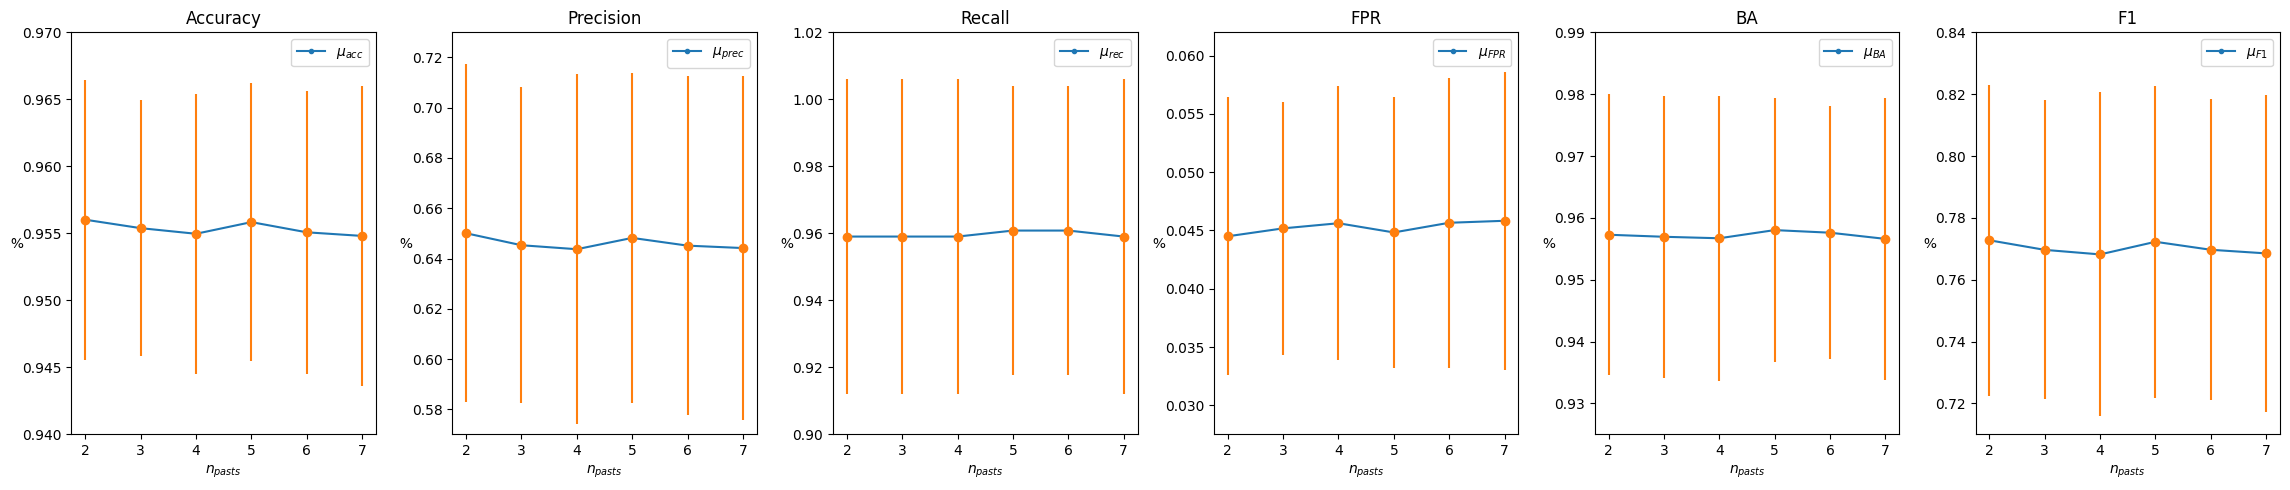

In [13]:
fig, ax = plt.subplots(1, 6, figsize = (23, 5))
labels = ['Accuracy', 'Precision', 'Recall', 'FPR', 'BA', 'F1']
lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$', '$\mu_{BA}$', '$\mu_{F1}$']
for i in range(Metrics.shape[2]):
    ax[i].plot(range(2, 2 + Metrics.shape[1]),
               np.mean(Metrics, axis = 0)[:, i],
               marker = '.', label = lab[i])

    ax[i].errorbar(range(2, 2 + Metrics.shape[1]),
                   np.mean(Metrics, axis = 0)[:, i],
                   yerr = np.std(Metrics, axis = 0)[:, i],
                   fmt='o')
    ax[i].set_xticks(range(2,2+Metrics.shape[1]),
                     list(range(2, 2+Metrics.shape[1])))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
    if labels[i] == 'Accuracy':
        ax[i].set_ylim(0.94, .97)
    if labels[i] == 'Precision':
        ax[i].set_ylim(0.57, .73)
    if labels[i] == 'Recall':
        ax[i].set_ylim(0.9, 1.02)
    if labels[i] == 'FPR':
        ax[i].set_ylim(0.0275, 0.062)
    if labels[i] == 'BA':
        ax[i].set_ylim(0.925, .99)
    if labels[i] == 'F1':
        ax[i].set_ylim(0.71, .84)
    ax[i].legend()
    plt.tight_layout()

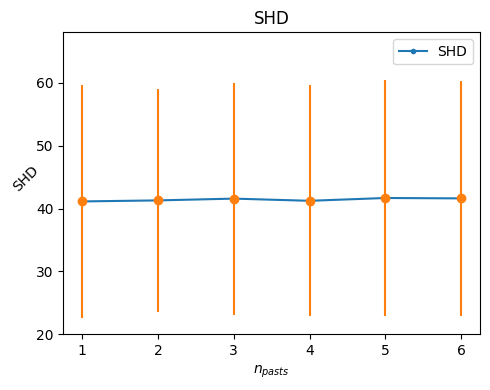

In [19]:
shds = np.array(shds)
fig, ax = plt.subplots(1, 1, figsize = (5, 4))
ax.plot(range(1, 1 + shds.shape[1]),
        np.mean(shds, axis = 0),
        marker = '.', label = 'SHD')
ax.errorbar(range(1, 1 + shds.shape[1]),
            np.mean(shds, axis = 0),
            yerr = np.std(shds, axis = 0),
            fmt='o')
ax.set_xticks(range(1,1+shds.shape[1]),
             list(range(1, 1+shds.shape[1])))
ax.set_xlabel('$n_{pasts}$')
ax.set_ylabel('SHD', rotation = 45)
ax.set_title(f'SHD')
ax.set_ylim(20, 68)
ax.legend()
plt.tight_layout()